# 04 — Normalising flow noise adapter

Replace the Gaussian adapter $q_\phi(z|y)$ with a conditional normalising flow
$z = T_\phi(\varepsilon; y)$ and keep the flow map frozen. The noise posterior $p(z|y)$ is
bimodal, so a Gaussian cannot represent it. VFM fine-tunes the flow map instead. Here the
adapter is made more expressive.

The experiment is built up in four stages, each testing one thing that could go wrong. Stage 0
asks whether the flow library works at all, by fitting an unconditional flow to checkerboard
samples. Stage 0.5 asks whether the flow is expressive enough, and whether it can use the
observation, by training it on pairs whose correct answer is already known. Stage 1 asks whether
reverse KL finds both modes, by training on a single fixed observation. Stage 2 asks whether it
still works when one network has to serve every observation.

## Setup

In [1]:
import math
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import zuko
from functools import partial
from pathlib import Path

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device, "| zuko", zuko.__version__)

torch.manual_seed(0)
np.random.seed(0)

CKPT_PRETRAINED = Path("../checkerboard_example/checkpoints")
OUT_DIR = Path("ckpts"); OUT_DIR.mkdir(exist_ok=True)
FIG_DIR = Path("figures/04"); FIG_DIR.mkdir(parents=True, exist_ok=True)
sigma = 0.1


def sample_checkerboard(n_samples, n_squares=4):
    x = np.random.rand(n_samples, 2)
    idx = (x * n_squares).astype(int)
    mask = (idx[:, 0] + idx[:, 1]) % 2 == 0
    while not mask.all():
        n_bad = (~mask).sum()
        x_new = np.random.rand(n_bad, 2)
        idx_new = (x_new * n_squares).astype(int)
        x[~mask] = x_new; idx[~mask] = idx_new
        mask = (idx[:, 0] + idx[:, 1]) % 2 == 0
    return 4.0 * (x - np.array([[0.5, 0.5]]))


def sample_y(x, sigma_obs):
    return x[:, :1] + sigma_obs * torch.randn(x.shape[0], 1, device=x.device, dtype=x.dtype)


class MeanFlowMLP(nn.Module):
    def __init__(self, hidden=256, depth=4):
        super().__init__()
        layers = []; dim = 4
        for _ in range(depth):
            layers += [nn.Linear(dim, hidden), nn.SiLU()]; dim = hidden
        layers += [nn.Linear(dim, 2)]
        self.net = nn.Sequential(*layers)
    def forward(self, z, r, t):
        return self.net(torch.cat([z, t, r], dim=1))


def f_theta(z, u_model, K=1):
    if z.ndim == 3:
        B, J, D = z.shape; z = z.reshape(B * J, D)
    ts = torch.linspace(0.0, 1.0, K + 1, device=z.device)
    for i in range(K, 0, -1):
        t_i = torch.full((z.shape[0], 1), ts[i].item(), device=z.device)
        r_i = torch.full((z.shape[0], 1), ts[i-1].item(), device=z.device)
        z = z - (t_i - r_i) * u_model(z, r_i, t_i)
    if 'J' in locals(): z = z.reshape(B, J, D)
    return z


# frozen decoder — never trained in this notebook
mf_model = MeanFlowMLP(512, 6).to(device)
mf_model.load_state_dict(torch.load(CKPT_PRETRAINED / "mf_model.pt", map_location=device))
mf_model.eval()
for p in mf_model.parameters():
    p.requires_grad_(False)


def log_std_normal(z):  # log N(z; 0, I), D=2
    return -0.5 * (z**2).sum(-1) - math.log(2 * math.pi)


def make_flow(context, arch="maf", transforms=4, hidden=64):
    cls = zuko.flows.MAF if arch == "maf" else zuko.flows.NSF
    return cls(features=2, context=context, transforms=transforms,
               hidden_features=(hidden, hidden), passes=2).to(device)


@torch.no_grad()
def mode_fracs(x, yv):
    """fractions of samples in the two filled cells crossed by the line x1=yv"""
    lo = np.floor(yv)
    on = (x[:, 0] >= lo) & (x[:, 0] < lo + 1)
    col = int(np.floor((yv / 4.0 + 0.5) * 4))
    rows = [j for j in range(4) if (col + j) % 2 == 0][:2]
    return tuple(round(float((on & (x[:, 1] >= j - 2) & (x[:, 1] < j - 1)).mean()), 3)
                 for j in rows)


@torch.no_grad()
def probe_slices(flow, K=4, n=1000):
    out = {}
    for yv in (-1.5, 0.5, 1.5):
        z = flow(torch.full((1, 1), yv, device=device)).sample((n,)).squeeze(1)
        out[yv] = mode_fracs(f_theta(z, mf_model, K=K).cpu().numpy(), yv)
    return out


device: cuda | zuko 1.6.0


## Stage 0 — does the flow library work

Unconditional flow, plain maximum likelihood on checkerboard samples. This only checks that
`log_prob` and sampling behave. The sharp board is harder to fit than the noise posterior the
adapter actually has to learn, so a poor fit here would not mean the architecture is wrong.

step 1000: nll 2.3535


step 2000: nll 2.3052


step 3000: nll 2.3052


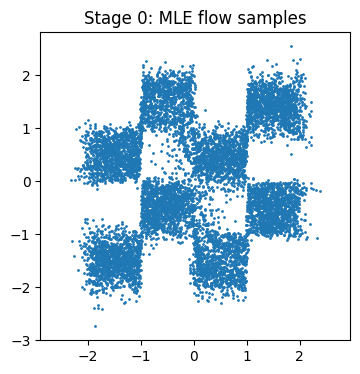

In [2]:
flow0 = make_flow(context=0)
opt = torch.optim.Adam(flow0.parameters(), lr=1e-3)
for i in range(1, 3001):
    xb = torch.tensor(sample_checkerboard(2048), dtype=torch.float32, device=device)
    loss = -flow0().log_prob(xb).mean()
    opt.zero_grad(set_to_none=True); loss.backward()
    torch.nn.utils.clip_grad_norm_(flow0.parameters(), 5.0); opt.step()
    if i % 1000 == 0:
        print(f"step {i}: nll {loss.item():.4f}")

with torch.no_grad():
    xs = flow0().sample((10_000,)).cpu().numpy()
plt.figure(figsize=(4, 4))
plt.scatter(xs[:, 0], xs[:, 1], s=1)
plt.axis("equal"); plt.title("Stage 0: MLE flow samples")
plt.savefig(FIG_DIR / "stage0_mle_samples.png", dpi=120, bbox_inches="tight")
plt.show()


## Stage 0.5 — is the flow expressive enough

Drawing $z \sim \mathcal{N}(0,I)$, $x = f_\theta(z, K{=}1)$ and $y = x_1 + \sigma\varepsilon$
gives exact $(z, y)$ pairs from the joint distribution. Fitting $q_\phi(z|y)$ to those pairs by
maximum likelihood has the true noise posterior as its optimum, so this tests the flow's capacity
and its use of the observation without the ELBO being involved.

The result is also the best any adapter can do with the flow map frozen, so it is used below as
the ceiling.

In [3]:
flow_oracle = make_flow(context=1)
opt = torch.optim.Adam(flow_oracle.parameters(), lr=1e-3)
for i in range(1, 5001):
    with torch.no_grad():
        z = torch.randn(2048, 2, device=device)
        y = sample_y(f_theta(z, mf_model, K=1), sigma)
    loss = -flow_oracle(y).log_prob(z).mean()
    opt.zero_grad(set_to_none=True); loss.backward()
    torch.nn.utils.clip_grad_norm_(flow_oracle.parameters(), 5.0); opt.step()
    if i % 1000 == 0:
        print(f"step {i}: nll {loss.item():.4f} | modes {probe_slices(flow_oracle)}")

torch.save(flow_oracle.state_dict(), OUT_DIR / "nf_adapter_oracle_mafT4.pt")


step 1000: nll 0.7575 | modes {-1.5: (0.572, 0.344), 0.5: (0.469, 0.369), 1.5: (0.432, 0.482)}


step 2000: nll 0.6441 | modes {-1.5: (0.532, 0.422), 0.5: (0.456, 0.41), 1.5: (0.449, 0.468)}


step 3000: nll 0.7012 | modes {-1.5: (0.499, 0.457), 0.5: (0.48, 0.436), 1.5: (0.427, 0.488)}


step 4000: nll 0.6793 | modes {-1.5: (0.531, 0.422), 0.5: (0.472, 0.458), 1.5: (0.463, 0.462)}


step 5000: nll 0.6597 | modes {-1.5: (0.549, 0.398), 0.5: (0.457, 0.475), 1.5: (0.469, 0.458)}


## Stage 1 — does reverse KL find both modes

A single fixed observation $y^* = 0.5$, a flow with no context, and the ELBO through the frozen
flow map.
$$L = \tfrac{1}{2\sigma^2}\big(y^* - f_\theta(z)_1\big)^2 + \log q(z)
- \log \mathcal{N}(z;0,I), \qquad z \sim q.$$
Reverse KL is mode-seeking, so this asks whether it still finds both modes now that stage 0.5 has
shown the flow is expressive enough.

In [4]:
flow1 = make_flow(context=0)
opt = torch.optim.AdamW(flow1.parameters(), lr=2e-4, weight_decay=1e-4)
ystar = 0.5
for i in range(1, 5001):
    z, logq = flow1().rsample_and_log_prob((2048,))
    obs = (0.5 / sigma**2) * (ystar - f_theta(z, mf_model, K=1)[:, 0])**2
    kl = logq - log_std_normal(z)
    loss = (obs + kl).mean()
    opt.zero_grad(set_to_none=True); loss.backward()
    torch.nn.utils.clip_grad_norm_(flow1.parameters(), 5.0); opt.step()
    if i % 1000 == 0:
        with torch.no_grad():
            zs = flow1().sample((1000,))
            m4 = mode_fracs(f_theta(zs, mf_model, K=4).cpu().numpy(), ystar)
        print(f"step {i}: obs {obs.mean().item():.3f} kl {kl.mean().item():.3f} modes(K=4) {m4}")


step 1000: obs 0.521 kl 2.315 modes(K=4) (0.509, 0.406)


step 2000: obs 0.504 kl 2.262 modes(K=4) (0.491, 0.453)


step 3000: obs 0.522 kl 2.233 modes(K=4) (0.471, 0.488)


step 4000: obs 0.473 kl 2.268 modes(K=4) (0.479, 0.48)


step 5000: obs 0.476 kl 2.270 modes(K=4) (0.459, 0.494)


## Stage 2 — does it work for every observation

The same recipe as stage 1, with the observation given to the flow as context so that one network
serves every observation. Only the adapter family differs from notebook 02's frozen-θ baseline.

In [5]:
from torch.utils.data import TensorDataset, DataLoader

flow_elbo = make_flow(context=1)
opt = torch.optim.AdamW(flow_elbo.parameters(), lr=2e-4, weight_decay=1e-4)
x_train = torch.tensor(sample_checkerboard(20_000), dtype=torch.float32)
loader = DataLoader(TensorDataset(x_train), batch_size=2048, shuffle=True, drop_last=True)
it = iter(loader)
for i in range(1, 20_001):
    try: (xb,) = next(it)
    except StopIteration:
        it = iter(loader); (xb,) = next(it)
    xb = xb.to(device)
    y = sample_y(xb, sigma)
    z, logq = flow_elbo(y).rsample_and_log_prob()
    obs = (0.5 / sigma**2) * (y[:, 0] - f_theta(z, mf_model, K=1)[:, 0])**2
    kl = logq - log_std_normal(z)
    loss = (obs + kl).mean()
    opt.zero_grad(set_to_none=True); loss.backward()
    torch.nn.utils.clip_grad_norm_(flow_elbo.parameters(), 5.0); opt.step()
    if i % 2000 == 0:
        print(f"step {i}: obs {obs.mean().item():.3f} kl {kl.mean().item():.3f} | modes {probe_slices(flow_elbo)}")

torch.save(flow_elbo.state_dict(), OUT_DIR / "nf_adapter_elbo_mafT4.pt")


step 2000: obs 0.892 kl 2.493 | modes {-1.5: (0.563, 0.375), 0.5: (0.063, 0.837), 1.5: (0.474, 0.428)}


step 4000: obs 0.748 kl 2.451 | modes {-1.5: (0.494, 0.458), 0.5: (0.154, 0.712), 1.5: (0.472, 0.414)}


step 6000: obs 0.601 kl 2.431 | modes {-1.5: (0.533, 0.424), 0.5: (0.405, 0.509), 1.5: (0.444, 0.464)}


step 8000: obs 0.591 kl 2.419 | modes {-1.5: (0.526, 0.438), 0.5: (0.504, 0.448), 1.5: (0.494, 0.42)}


step 10000: obs 0.581 kl 2.375 | modes {-1.5: (0.485, 0.469), 0.5: (0.424, 0.534), 1.5: (0.419, 0.511)}


step 12000: obs 0.517 kl 2.405 | modes {-1.5: (0.539, 0.423), 0.5: (0.459, 0.513), 1.5: (0.444, 0.48)}


step 14000: obs 0.552 kl 2.416 | modes {-1.5: (0.502, 0.455), 0.5: (0.444, 0.519), 1.5: (0.46, 0.465)}


step 16000: obs 0.557 kl 2.379 | modes {-1.5: (0.505, 0.463), 0.5: (0.454, 0.509), 1.5: (0.432, 0.487)}


step 18000: obs 0.523 kl 2.398 | modes {-1.5: (0.53, 0.426), 0.5: (0.461, 0.506), 1.5: (0.429, 0.497)}


step 20000: obs 0.573 kl 2.364 | modes {-1.5: (0.497, 0.468), 0.5: (0.423, 0.545), 1.5: (0.455, 0.478)}


## Evaluation

Three methods are compared: Gaussian (rKL), NF (fKL) from stage 0.5, and VFM.

One draw of B=10,000 measurements is shared by every method and every table, truncated to
$|y| \le 1.9$, which is about 95% of the mass of $p(y)$. Beyond the board edge the rejection
acceptance falls below $10^{-4}$ and exact pullback sampling becomes intractable. The same
restriction is applied to every method. J=100 samples are drawn per side per measurement.

Table 1 is MMD in noise space at K=1, between $q_\phi(z|y)$ and the true pullback $p(z|y)$ of
that method's own generator. Pullback samples come from rejection in z-space, proposing
$z \sim \mathcal{N}(0,I)$ and accepting with probability
$\exp(-(y - f_\theta(z)_1)^2 / 2\sigma^2)$.

Table 2 is MMD in data space at K=1 and K=4, between the decoded samples and the true posterior
$p(x|y)$, which is shared across methods.

The figures use two fixed observations, an interior one at $y = +0.5$ and a cell-boundary one at
$y = 0.0$, with 2,000 points per panel.

In [6]:
# models under evaluation (frozen generator + Gaussian / NF adapters; VFM pair)
class Adapter(nn.Module):
    def __init__(self, hidden=128, depth=3, z_dim=2):
        super().__init__()
        layers = []; dim = 1
        for _ in range(depth):
            layers += [nn.Linear(dim, hidden), nn.SiLU()]; dim = hidden
        self.backbone = nn.Sequential(*layers)
        self.mu = nn.Linear(dim, z_dim); self.log_std = nn.Linear(dim, z_dim)
    def forward(self, y):
        h = self.backbone(y)
        return self.mu(h), self.log_std(h).clamp(-6.0, 3.0)


gauss_adapter = Adapter(256, 4, 2).to(device)
gauss_adapter.load_state_dict(torch.load(OUT_DIR / "adapter_only_model.pt", map_location=device)["adapter"])
gauss_adapter.eval()

vfm_ck = torch.load(OUT_DIR / "vfm_adapter_tau_100.0_alpha_1.0_ema.pt", map_location=device)
vfm_gen = MeanFlowMLP(512, 6).to(device); vfm_gen.load_state_dict(vfm_ck["mf_model"]); vfm_gen.eval()
vfm_adapter = Adapter(256, 4, 2).to(device); vfm_adapter.load_state_dict(vfm_ck["adapter"]); vfm_adapter.eval()
flow_oracle.eval()

B_EVAL, J_EVAL = 10_000, 100


@torch.no_grad()
def decode_chunked(z, gen, K=1, chunk=262_144):
    return torch.cat([f_theta(zc, gen, K=K) for zc in z.split(chunk)])


@torch.no_grad()
def reject_z_batch(y, gen, J, P=256, max_rounds=2000):
    """exact pullback samples p(z|y) for a whole batch of y at once.
    Propose z~N(0,I), accept w.p. exp(-(y - f(z)_1)^2 / 2 sigma^2), K=1 decode.
    Each round proposes only for the still-unfilled y's."""
    B_ = y.shape[0]
    out = torch.empty(B_, J, 2, device=device)
    filled = torch.zeros(B_, dtype=torch.long, device=device)
    for _ in range(max_rounds):
        active = (filled < J).nonzero(as_tuple=True)[0]
        if active.numel() == 0:
            break
        A = active.numel()
        z = torch.randn(A, P, 2, device=device)
        x1 = decode_chunked(z.reshape(-1, 2), gen, K=1)[:, 0].reshape(A, P)
        acc = torch.rand(A, P, device=device) < torch.exp(-0.5 * ((y[active] - x1) / sigma)**2)
        rank = acc.cumsum(dim=1)
        slot = filled[active].unsqueeze(1) + rank - 1
        valid = acc & (slot < J)
        out[active.unsqueeze(1).expand_as(valid)[valid], slot[valid]] = z[valid]
        filled[active] = torch.minimum(filled[active] + acc.sum(dim=1),
                                       torch.full_like(filled[active], J))
    n_bad = int((filled < J).sum())
    assert n_bad == 0, f"z-space rejection did not fill {n_bad} y's; worst |y|={float(y[(filled < J).nonzero(as_tuple=True)[0]].abs().max()):.3f}"
    return out


@torch.no_grad()
def reject_x_batch(y, J, P=256, max_rounds=2000):
    """exact true-posterior samples p(x|y): propose x ~ checkerboard,
    accept w.p. exp(-(y - x_1)^2 / 2 sigma^2). Subset-per-round as above."""
    B_ = y.shape[0]
    out = torch.empty(B_, J, 2, device=device)
    filled = torch.zeros(B_, dtype=torch.long, device=device)
    for _ in range(max_rounds):
        active = (filled < J).nonzero(as_tuple=True)[0]
        if active.numel() == 0:
            break
        A = active.numel()
        xp = torch.tensor(sample_checkerboard(A * P).reshape(A, P, 2),
                          dtype=torch.float32, device=device)
        acc = torch.rand(A, P, device=device) < torch.exp(-0.5 * ((y[active] - xp[:, :, 0]) / sigma)**2)
        rank = acc.cumsum(dim=1)
        slot = filled[active].unsqueeze(1) + rank - 1
        valid = acc & (slot < J)
        out[active.unsqueeze(1).expand_as(valid)[valid], slot[valid]] = xp[valid]
        filled[active] = torch.minimum(filled[active] + acc.sum(dim=1),
                                       torch.full_like(filled[active], J))
    n_bad = int((filled < J).sum())
    assert n_bad == 0, f"x-space rejection did not fill {n_bad} y's"
    return out


@torch.no_grad()
def mmd_batched(X, Y, chunk=1000):
    """X, Y: (B, J, 2) -> (B,) per-y MMD. Unbiased, RBF, per-y median-heuristic
    bandwidth from the cross-set squared distances."""
    vals = []
    for a, b in zip(X.split(chunk), Y.split(chunk)):
        d_ab = torch.cdist(a, b)**2
        d_aa = torch.cdist(a, a)**2
        d_bb = torch.cdist(b, b)**2
        med = d_ab.flatten(1).median(dim=1).values.clamp(min=1e-12)
        g = (1.0 / (2 * med)).view(-1, 1, 1)
        Kaa = torch.exp(-g * d_aa); Kbb = torch.exp(-g * d_bb); Kab = torch.exp(-g * d_ab)
        Jn = a.shape[1]
        eye = torch.eye(Jn, device=a.device).unsqueeze(0)
        m2 = ((Kaa * (1 - eye)).sum(dim=(1, 2))) / (Jn * (Jn - 1)) \
           + ((Kbb * (1 - eye)).sum(dim=(1, 2))) / (Jn * (Jn - 1)) - 2 * Kab.mean(dim=(1, 2))
        vals.append(torch.sqrt(torch.clamp(m2, min=0)))
    return torch.cat(vals)


@torch.no_grad()
def q_samples_gauss(adapter, y, J):
    mu, ls = adapter(y)
    e = torch.randn(y.shape[0], J, 2, device=device)
    return mu.unsqueeze(1) + torch.exp(ls).unsqueeze(1) * e


@torch.no_grad()
def q_samples_flow(flow, y, J, chunk=2000):
    return torch.cat([flow(yb).sample((J,)).movedim(0, 1) for yb in y.split(chunk)])


# the shared evaluation set (truncated to |y| <= 1.9; see protocol)
ys = []
while sum(t.shape[0] for t in ys) < B_EVAL:
    x_b = torch.tensor(sample_checkerboard(2 * B_EVAL), dtype=torch.float32, device=device)
    y_b = sample_y(x_b, sigma)
    ys.append(y_b[y_b.abs().squeeze(1) <= 1.9])
y_eval = torch.cat(ys)[:B_EVAL]
print("shared evaluation set:", tuple(y_eval.shape), "| max |y| =", float(y_eval.abs().max()))


shared evaluation set: (10000, 1) | max |y| = 1.8999900817871094


In [7]:
# Table 1: noise-space MMD, K=1 (q(z|y) vs own-generator pullback p(z|y))
print("z-space rejection (frozen generator)...")
p_z_frozen = reject_z_batch(y_eval, mf_model, J_EVAL)
print("z-space rejection (VFM generator)...")
p_z_vfm = reject_z_batch(y_eval, vfm_gen, J_EVAL)

noise_rows = {
    "Gaussian (rKL)": mmd_batched(q_samples_gauss(gauss_adapter, y_eval, J_EVAL), p_z_frozen),
    "nf-forward-kl":     mmd_batched(q_samples_flow(flow_oracle, y_eval, J_EVAL), p_z_frozen),
    "vfm":               mmd_batched(q_samples_gauss(vfm_adapter, y_eval, J_EVAL), p_z_vfm),
}
print(f"\nnoise-space MMD, K=1  (B={B_EVAL}, J={J_EVAL}; mean ± std over y)")
for name, v in noise_rows.items():
    print(f"  {name:20s} {v.mean():.4f} ± {v.std():.4f}")


z-space rejection (frozen generator)...


z-space rejection (VFM generator)...



noise-space MMD, K=1  (B=10000, J=100; mean ± std over y)
  gaussian-strawman    0.3089 ± 0.1329
  nf-forward-kl        0.0345 ± 0.0489
  vfm                  0.0338 ± 0.0481


In [8]:
# Table 2: data-space MMD, K=1 and K=4 (decoded q vs true p(x|y))
print("x-space rejection (true posterior)...")
p_x_true = reject_x_batch(y_eval, J_EVAL)

Z_Q = {
    "Gaussian (rKL)": (q_samples_gauss(gauss_adapter, y_eval, J_EVAL), mf_model),
    "nf-forward-kl":     (q_samples_flow(flow_oracle, y_eval, J_EVAL), mf_model),
    "vfm":               (q_samples_gauss(vfm_adapter, y_eval, J_EVAL), vfm_gen),
}
for K_dec in (1, 4):
    print(f"\ndata-space MMD, K={K_dec}  (B={B_EVAL}, J={J_EVAL}; mean ± std over y)")
    for name, (zq, gen) in Z_Q.items():
        xq = decode_chunked(zq.reshape(-1, 2), gen, K=K_dec).reshape(B_EVAL, J_EVAL, 2)
        v = mmd_batched(xq, p_x_true)
        print(f"  {name:20s} {v.mean():.4f} ± {v.std():.4f}")


x-space rejection (true posterior)...



data-space MMD, K=1  (B=10000, J=100; mean ± std over y)


  gaussian-strawman    0.3089 ± 0.1664


  nf-forward-kl        0.0511 ± 0.0617


  vfm                  0.0363 ± 0.0544

data-space MMD, K=4  (B=10000, J=100; mean ± std over y)


  gaussian-strawman    0.3046 ± 0.1665


  nf-forward-kl        0.0467 ± 0.0608


  vfm                  0.0333 ± 0.0529


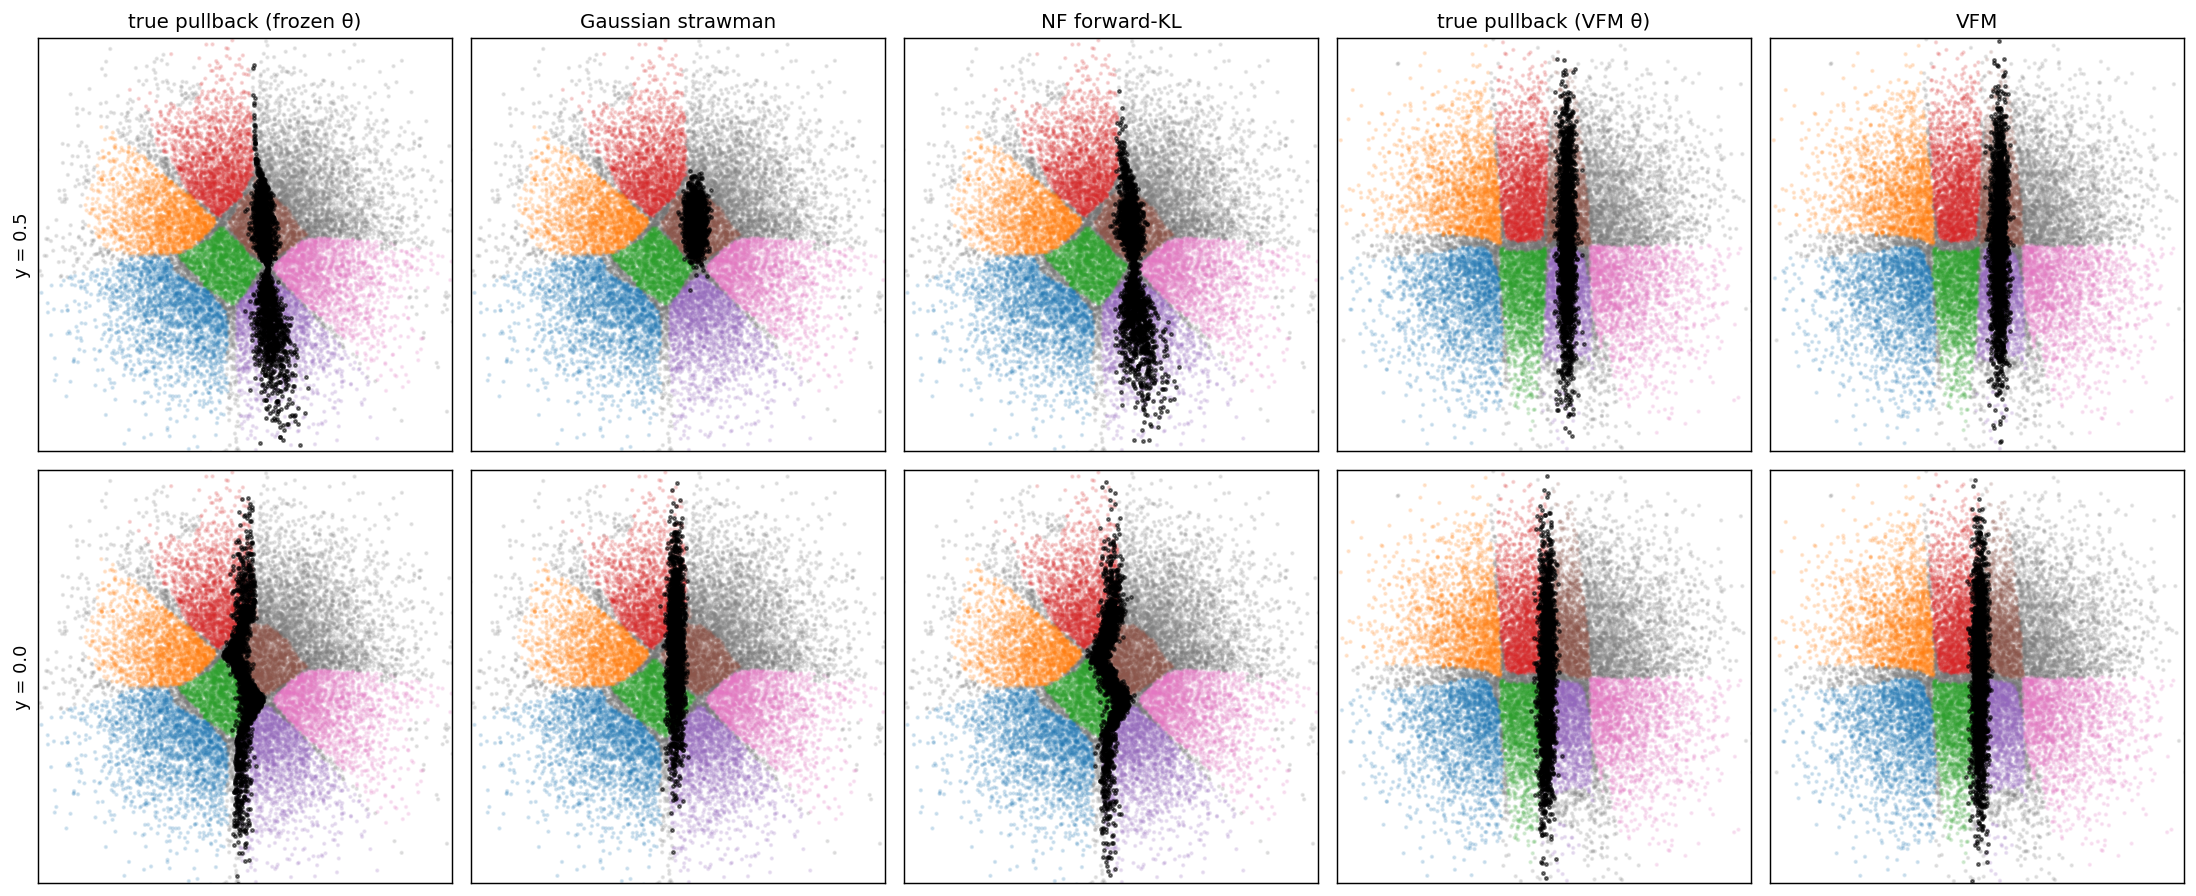

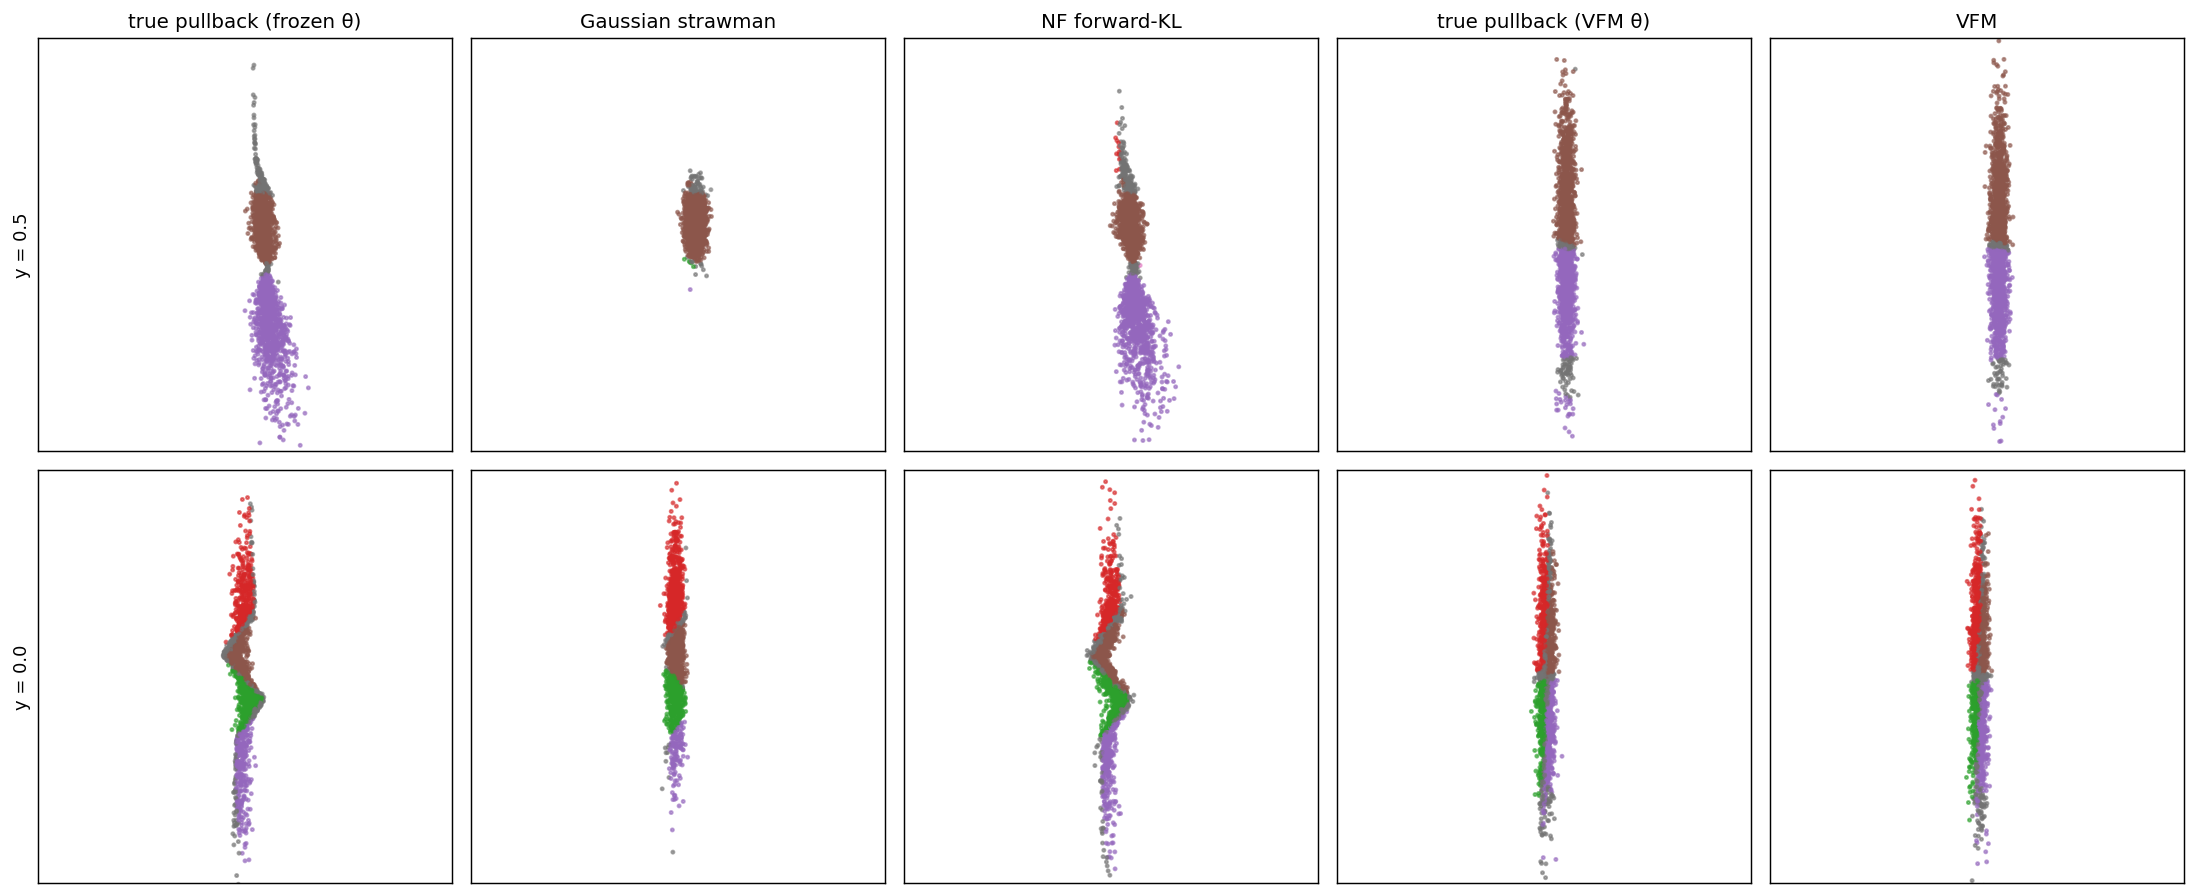

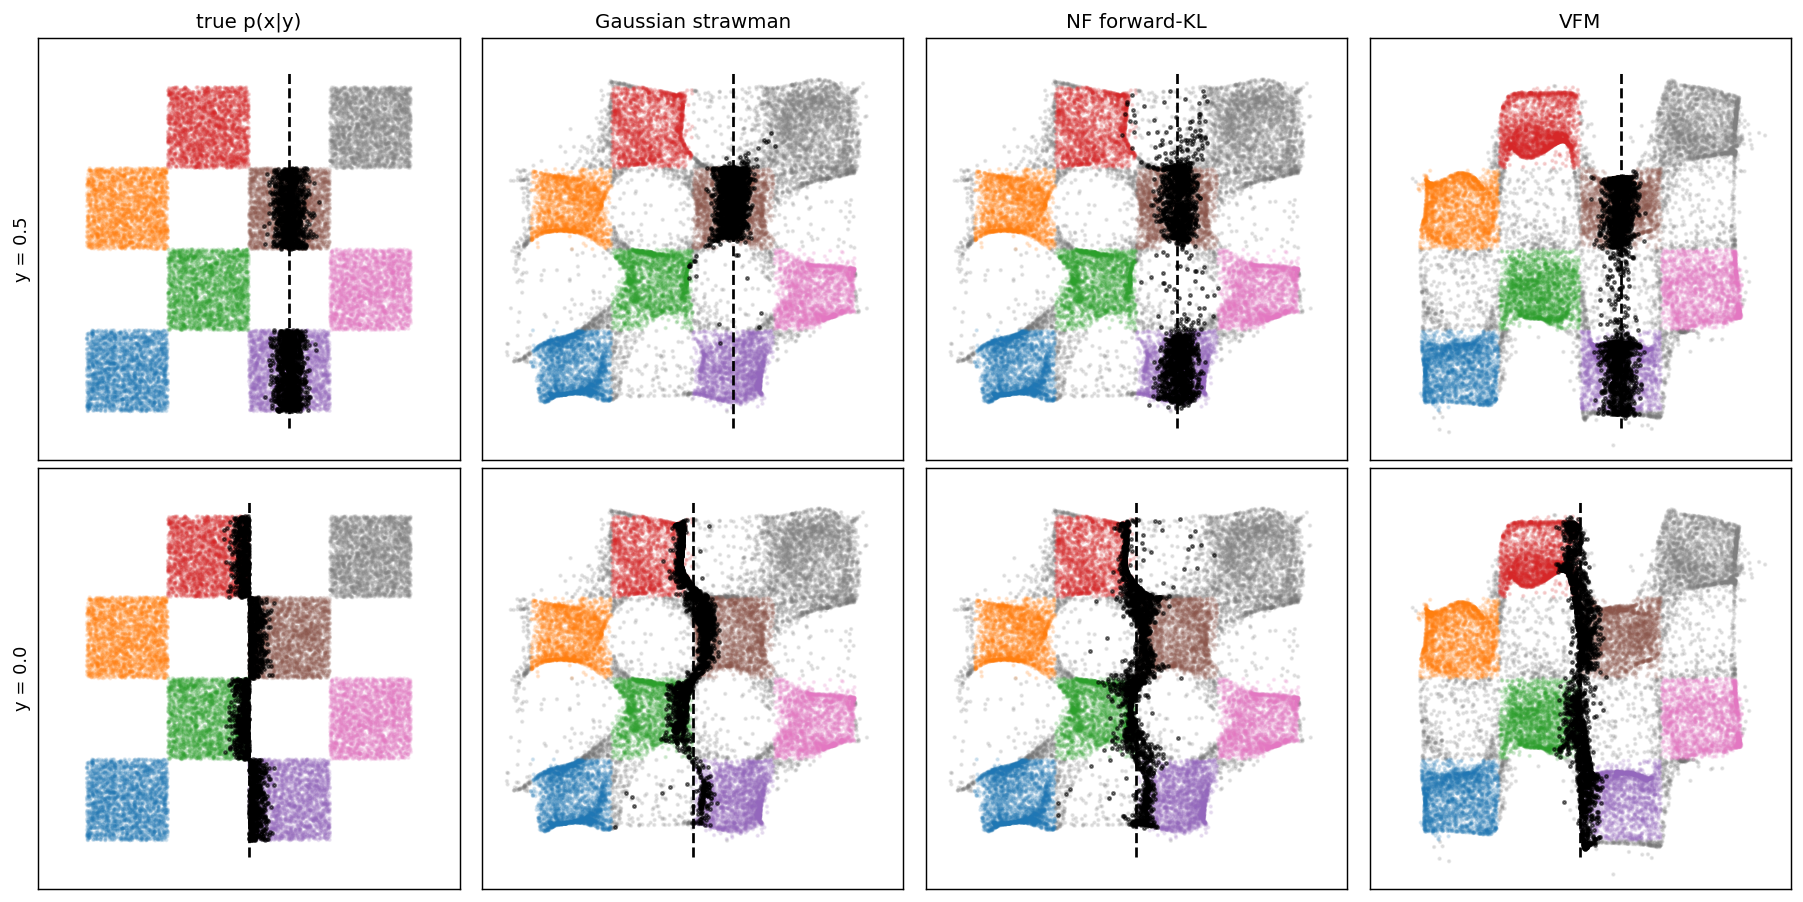

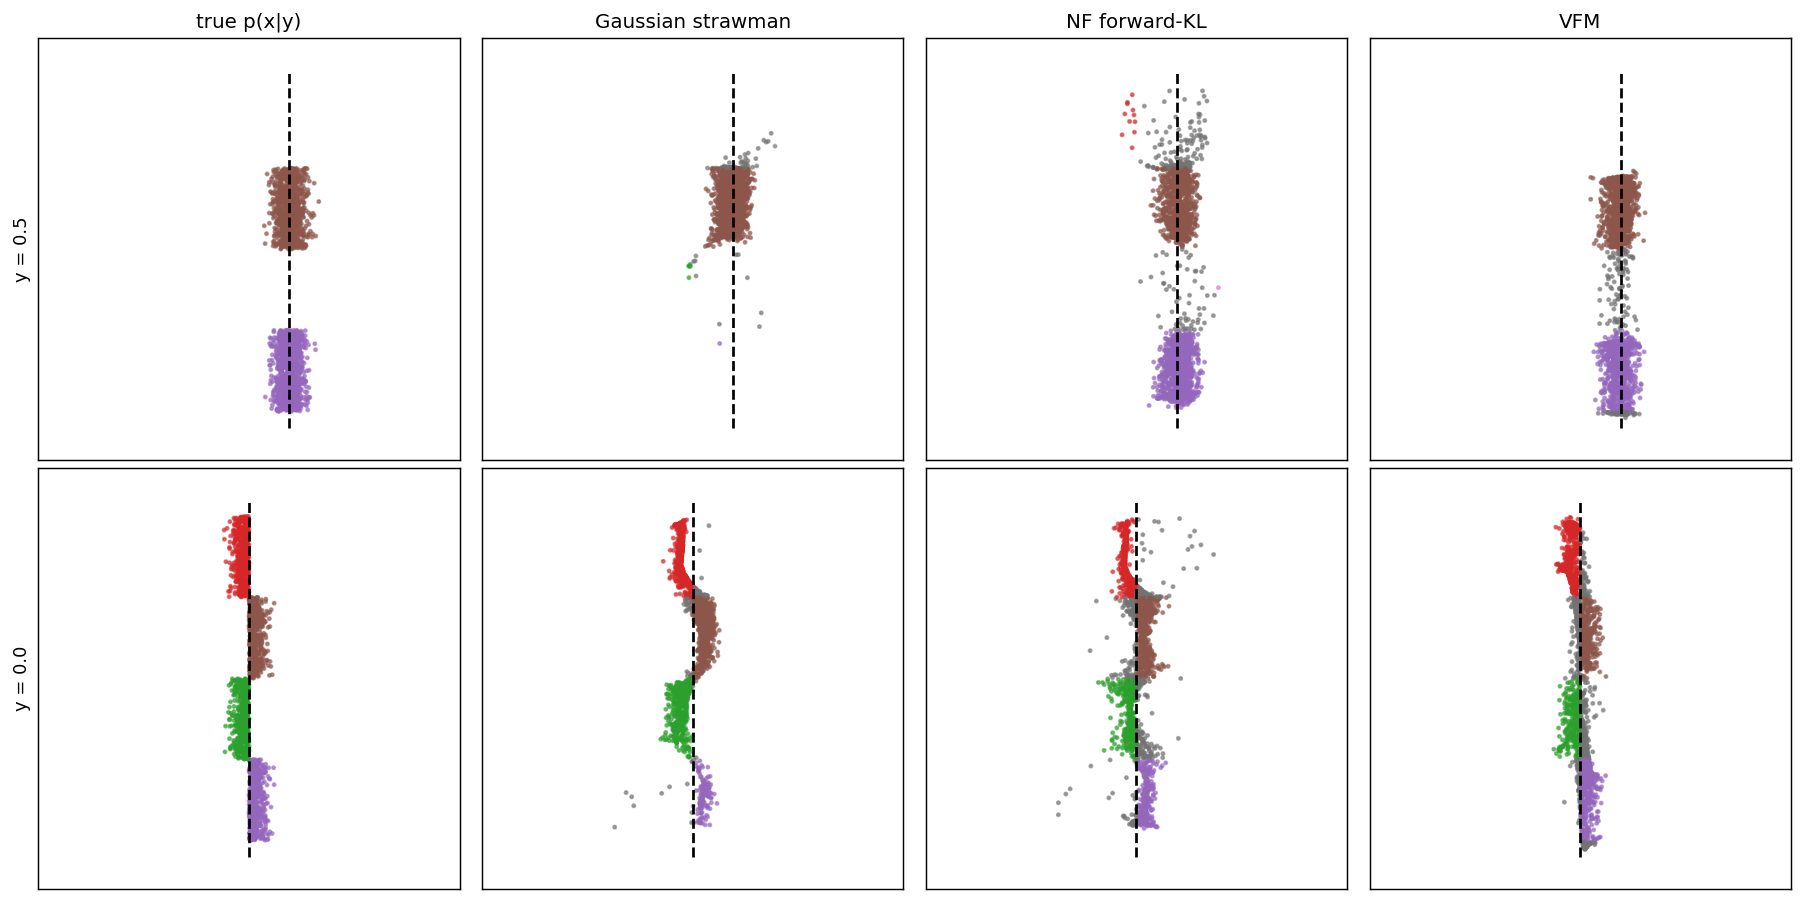

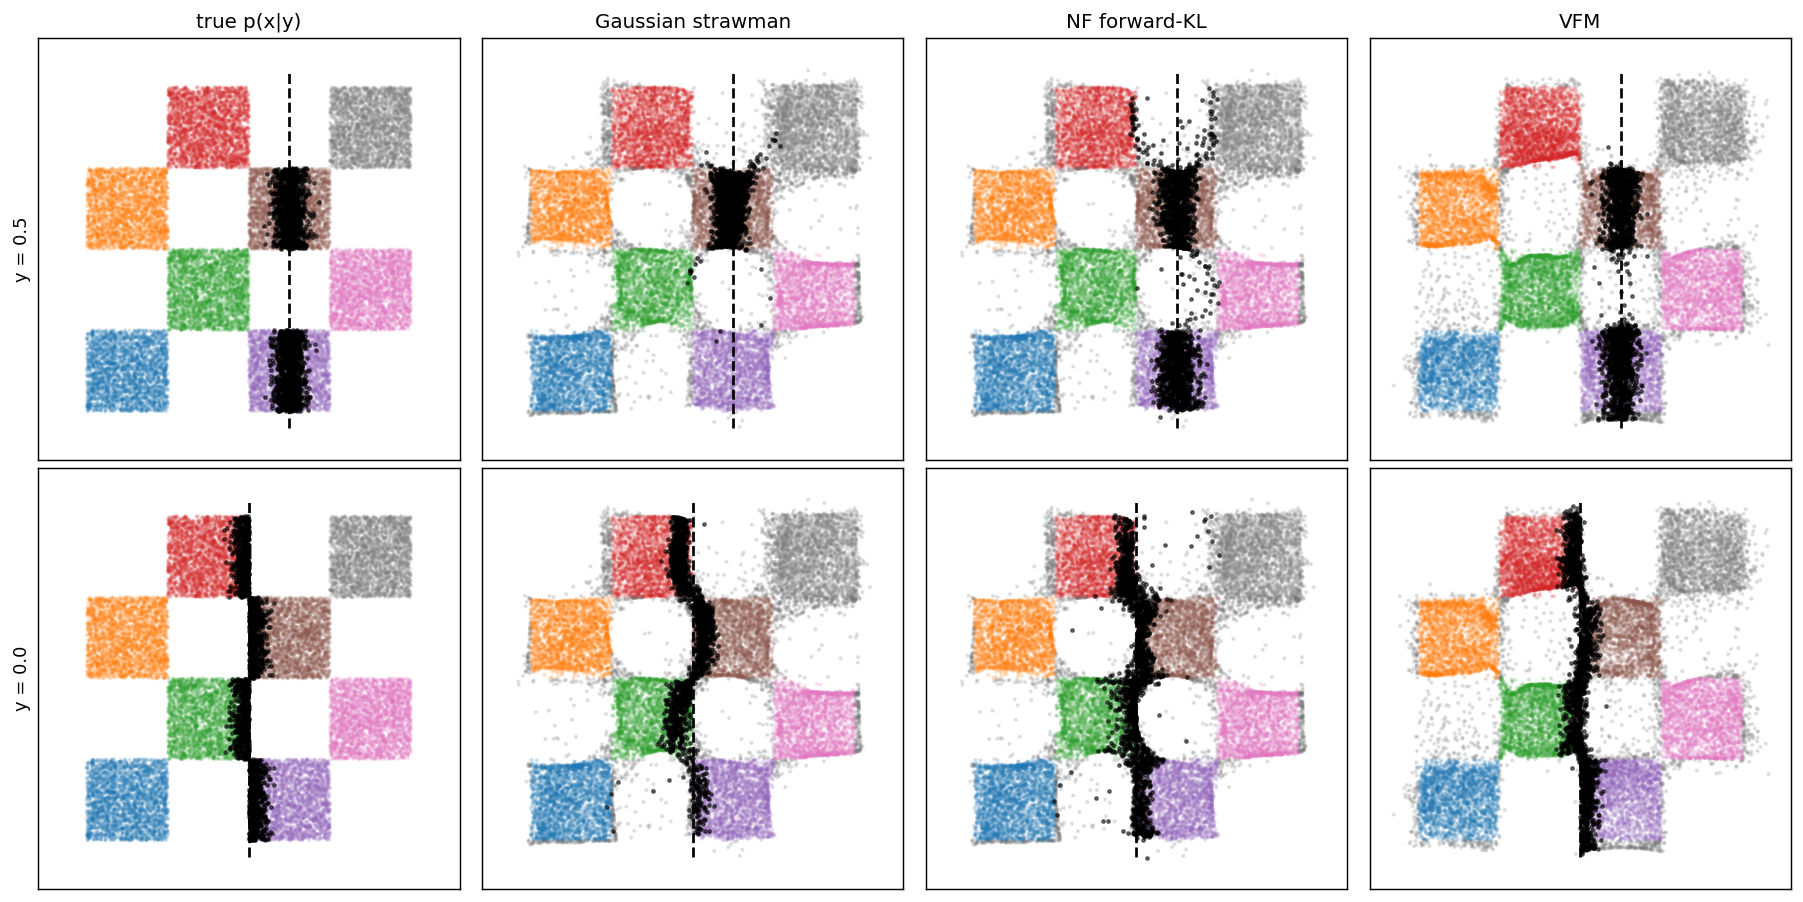

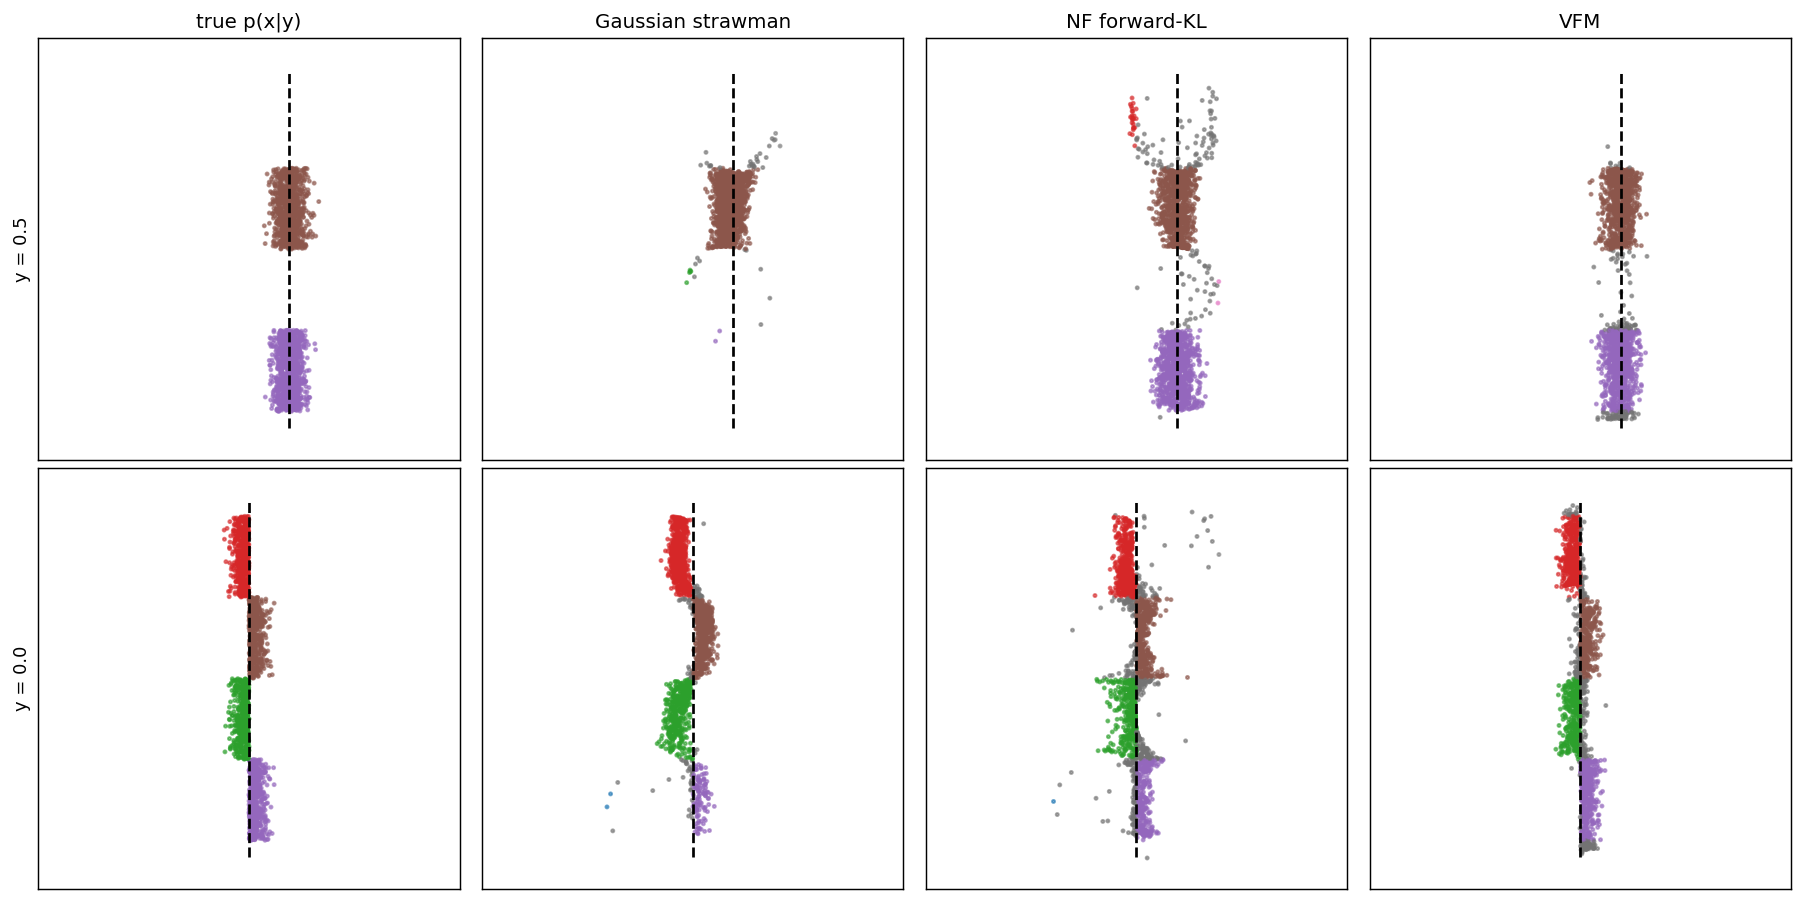

In [ ]:
# Figures: interior y=+0.5 and boundary y=0.0
# Shared style: low-alpha colored background showing the generator's geometry
# (points colored by the cell their K=1 decode lands in; grey = off-manifold),
# with the panel's 2,000 evaluation samples in black on top.
# Noise space: background = 20k prior z, colored by decode destination.
# Data space:  background = the 20k decoded points themselves (true-posterior
#              panel uses true checkerboard samples); dashed observation line.
N_PLOT = 2000
N_BG = 20_000
Y_FIGS = (0.5, 0.0)

FILLED = [(i, j) for i in range(4) for j in range(4) if (i + j) % 2 == 0]
cell_color = {cid: plt.get_cmap("tab10")(k)
              for k, cid in enumerate(sorted(i * 4 + j for (i, j) in FILLED))}
OFF = (0.45, 0.45, 0.45, 1.0)


def cell_colors_of(x):
    """color per point by the filled cell containing x (grey otherwise)"""
    u = x / 4.0 + 0.5
    inside = ((u >= 0) & (u < 1)).all(dim=1)
    ij = torch.floor(u * 4).long().clamp(0, 3)
    cid = (ij[:, 0] * 4 + ij[:, 1]).cpu().numpy()
    ok = (inside & ((ij[:, 0] + ij[:, 1]) % 2 == 0)).cpu().numpy()
    return np.array([cell_color[cc] if k else OFF for cc, k in zip(cid, ok)])


def panels_for(yv):
    y1 = torch.full((1, 1), yv, device=device)
    pzf = reject_z_batch(y1, mf_model, N_PLOT, P=8192)[0]
    pzv = reject_z_batch(y1, vfm_gen, N_PLOT, P=8192)[0]
    px = reject_x_batch(y1, N_PLOT, P=8192)[0]
    qg = q_samples_gauss(gauss_adapter, y1, N_PLOT)[0]
    qf = q_samples_flow(flow_oracle, y1, N_PLOT)[0]
    qv = q_samples_gauss(vfm_adapter, y1, N_PLOT)[0]
    return pzf, pzv, px, qg, qf, qv


with torch.no_grad():
    data = {yv: panels_for(yv) for yv in Y_FIGS}
    bg = {}
    for gk, gen in (("frozen", mf_model), ("vfm", vfm_gen)):
        zb = torch.randn(N_BG, 2, device=device)
        xb = f_theta(zb, gen, K=1)
        cols_b = cell_colors_of(xb)
        bg[gk] = {"z": zb.cpu().numpy(), "x": xb.cpu().numpy(), "c": cols_b}
    xb_true = torch.tensor(sample_checkerboard(N_BG), dtype=torch.float32, device=device)
    bg["true"] = {"x": xb_true.cpu().numpy(), "c": cell_colors_of(xb_true)}

# noise space: 2 rows x 5 cols
COLS_Z = [("true pullback (frozen θ)", "frozen"), ("Gaussian (rKL)", "frozen"),
          ("NF forward-KL", "frozen"), ("true pullback (VFM θ)", "vfm"), ("VFM", "vfm")]

fig, axes = plt.subplots(2, 5, figsize=(17, 7))
for r_i, yv in enumerate(Y_FIGS):
    pzf, pzv, px, qg, qf, qv = data[yv]
    fg = [pzf, qg, qf, pzv, qv]
    for c, (name, gk) in enumerate(COLS_Z):
        ax = axes[r_i, c]
        ax.scatter(bg[gk]["z"][:, 0], bg[gk]["z"][:, 1], s=2, c=bg[gk]["c"],
                   alpha=0.15, rasterized=True)
        p = fg[c].cpu().numpy()
        ax.scatter(p[:, 0], p[:, 1], s=3, c="k", alpha=0.5)
        ax.set_xlim(-3.2, 3.2); ax.set_ylim(-3.2, 3.2)
        ax.set_xticks([]); ax.set_yticks([])
        if r_i == 0: ax.set_title(name, fontsize=11)
        if c == 0: ax.set_ylabel(f"y = {yv}")
plt.tight_layout()
plt.savefig(FIG_DIR / "eval_stage05_noise_space_A.png", dpi=130, bbox_inches="tight")
plt.show()

# variant B (both spaces): no background; samples coloured by the cell their
# K=1 decode lands in (noise space), or the cell they lie in (data space)
fig, axes = plt.subplots(2, 5, figsize=(17, 7))
for r_i, yv in enumerate(Y_FIGS):
    pzf, pzv, px, qg, qf, qv = data[yv]
    fg = [pzf, qg, qf, pzv, qv]
    for c, (name, gk) in enumerate(COLS_Z):
        ax = axes[r_i, c]
        pts = fg[c]
        gen = mf_model if gk == "frozen" else vfm_gen
        with torch.no_grad():
            pc = cell_colors_of(f_theta(pts, gen, K=1))
        p = pts.cpu().numpy()
        ax.scatter(p[:, 0], p[:, 1], s=3, c=pc, alpha=0.6)
        ax.set_xlim(-3.2, 3.2); ax.set_ylim(-3.2, 3.2)
        ax.set_xticks([]); ax.set_yticks([])
        if r_i == 0: ax.set_title(name, fontsize=11)
        if c == 0: ax.set_ylabel(f"y = {yv}")
plt.tight_layout()
plt.savefig(FIG_DIR / "eval_stage05_noise_space_B.png", dpi=130, bbox_inches="tight")
plt.show()

# data space, variants A and B, K=1 and K=4
for K_dec in (1, 4):
    with torch.no_grad():
        bgK = {}
        for gk, gen in (("frozen", mf_model), ("vfm", vfm_gen)):
            zb = torch.randn(N_BG, 2, device=device)
            xbK = f_theta(zb, gen, K=K_dec)
            bgK[gk] = {"x": xbK.cpu().numpy(), "c": cell_colors_of(xbK)}
        bgK["true"] = bg["true"]

    for variant in ("A", "B"):
        fig, axes = plt.subplots(2, 4, figsize=(14, 7))
        for r_i, yv in enumerate(Y_FIGS):
            pzf, pzv, px, qg, qf, qv = data[yv]
            with torch.no_grad():
                cols = [("true p(x|y)", "true", px),
                        ("Gaussian (rKL)", "frozen", f_theta(qg, mf_model, K=K_dec)),
                        ("NF forward-KL", "frozen", f_theta(qf, mf_model, K=K_dec)),
                        ("VFM", "vfm", f_theta(qv, vfm_gen, K=K_dec))]
            for c, (name, gk, pts) in enumerate(cols):
                ax = axes[r_i, c]
                p = pts.cpu().numpy()
                if variant == "A":
                    ax.scatter(bgK[gk]["x"][:, 0], bgK[gk]["x"][:, 1], s=2,
                               c=bgK[gk]["c"], alpha=0.15, rasterized=True)
                    ax.scatter(p[:, 0], p[:, 1], s=3, c="k", alpha=0.5)
                else:
                    ax.scatter(p[:, 0], p[:, 1], s=3, c=cell_colors_of(pts), alpha=0.6)
                ax.vlines(yv, -2.2, 2.2, linestyles="dashed", colors="black")
                ax.set_xlim(-2.6, 2.6); ax.set_ylim(-2.6, 2.6); ax.set_aspect("equal")
                ax.set_xticks([]); ax.set_yticks([])
                if r_i == 0: ax.set_title(name, fontsize=11)
                if c == 0: ax.set_ylabel(f"y = {yv}")
        plt.tight_layout()
        plt.savefig(FIG_DIR / f"eval_stage05_data_space_{variant}_K{K_dec}.png",
                    dpi=130, bbox_inches="tight")
        plt.show()
